In [164]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
from scipy.spatial.distance import mahalanobis
from simulating import simulate, create_tables


### Data summaries

##### Observed Data

In [165]:
df_infected = pd.read_csv("data/infected_timeseries.csv")
df_rewiring = pd.read_csv("data/rewiring_timeseries.csv")
df_final = pd.read_csv("data/final_degree_histograms.csv")

t = np.arange(201)
x_deg = np.arange(31)
true_infected_avg = df_infected["infected_fraction"].groupby(df_infected["time"]).mean().to_numpy()
true_infected_std = df_infected["infected_fraction"].groupby(df_infected["time"]).std().to_numpy()
true_rewiring_avg = df_rewiring["rewire_count"].groupby(df_rewiring["time"]).mean().to_numpy()
true_rewiring_std = df_rewiring["rewire_count"].groupby(df_rewiring["time"]).std().to_numpy()
true_final_avg = df_final["count"].groupby(df_final["degree"]).mean().to_numpy()
true_final_std = df_final["count"].groupby(df_final["degree"]).std().to_numpy()

df_infected_impt = df_infected["infected_fraction"].to_numpy()
df_rewiring_impt = df_rewiring["rewire_count"].to_numpy()
df_final_impt = df_final["count"].to_numpy()

true_infected = df_infected_impt.reshape(40, 201)
true_rewire = df_rewiring_impt.reshape(40, 201)
true_degree = df_final_impt.reshape(40, 31)

N = 200
p = 0.05
lamd = (N - 1) * p
k = np.arange(31)
probs = stats.poisson.pmf(k, lamd)
counts = N * probs

##### Simulated Data

In [166]:
data1 = np.load('simulation_results.npz')
data2 = np.load('simulation_results_1.npz')
data3 = np.load('simulation_results_2.npz')
param_values = np.vstack([data1['param_values'], data2['param_values'], data3['param_values']])
infected_sim = np.vstack([data1['infected_sim'], data2['infected_sim'], data3['infected_sim']])
rewire_sim   = np.vstack([data1['rewire_sim'], data2['rewire_sim'], data3['rewire_sim']])
degree_sim   = np.vstack([data1['degree_sim'], data2['degree_sim'], data3['degree_sim']])

In [167]:
true_infected_1 = true_infected[0, :]
true_rewire_1   = true_rewire[0, :]
true_degree_1   = true_degree[0, :]
infected_sim_1  = infected_sim[:, 0, :]
rewire_sim_1    = rewire_sim[:, 0, :]
degree_sim_1    = degree_sim[:, 0, :]

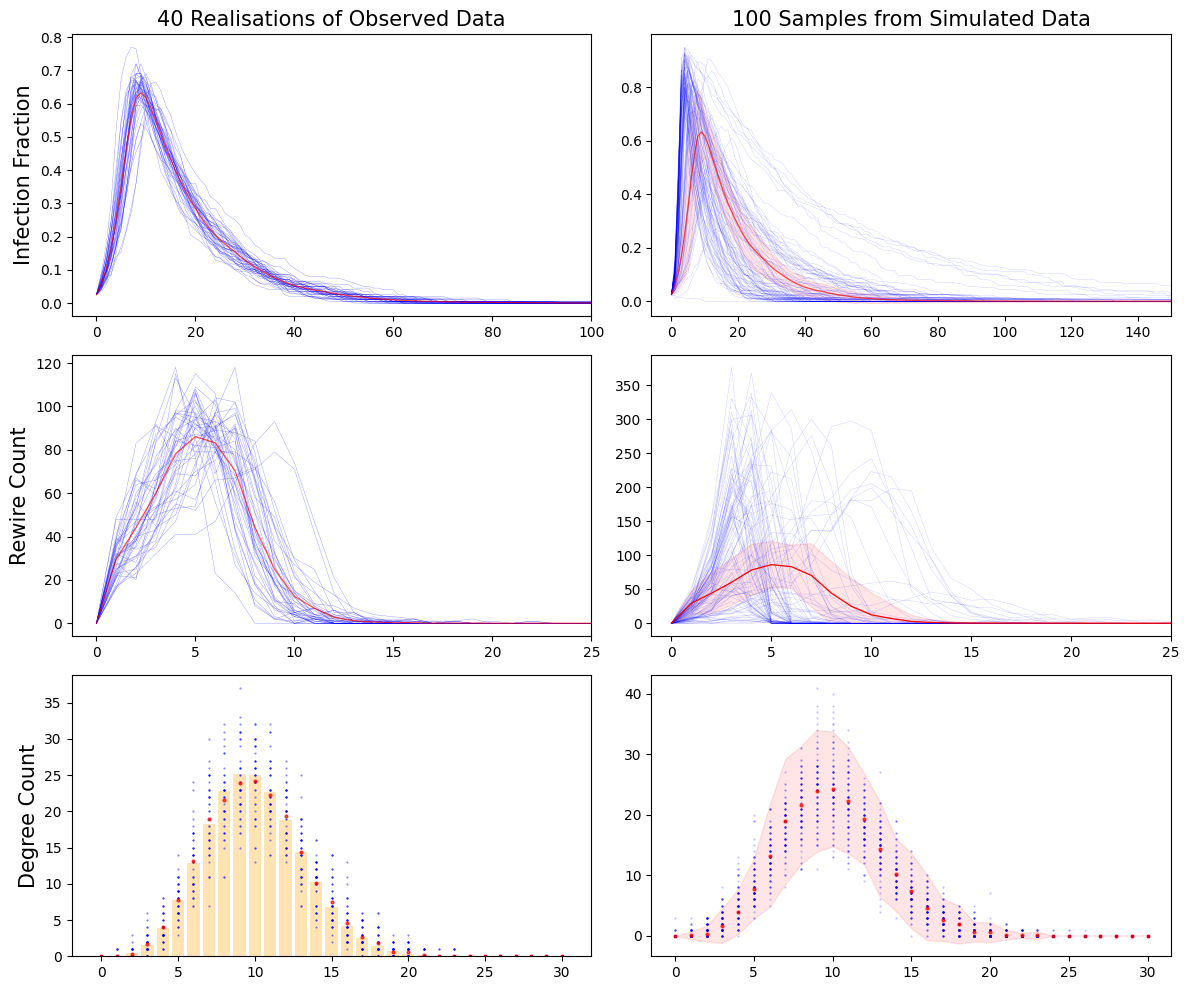

In [168]:
fig, axs = plt.subplots(3, 2, figsize = (12, 10))

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]

ax11.set_title("40 Realisations of Observed Data", fontsize = 15)
ax12.set_title("100 Samples from Simulated Data", fontsize = 15)
ax31.bar(k, counts, color = 'orange', alpha = 0.3)

for i in range(40):
    ax11.plot(df_infected_impt[201 * i: 201 + 201 * i], alpha = 0.5, linewidth = 0.25, color = "blue")
    ax21.plot(df_rewiring_impt[201 * i: 201 + 201 * i], alpha = 0.5, linewidth = 0.25, color = "blue")
    ax31.scatter(x_deg, df_final_impt[31 * i: 31 + 31 * i], alpha = 0.5, s = 0.25, color = 'blue')
    
for i in range(100):
    ax12.plot(infected_sim_1[i, ], alpha = 0.25, linewidth = 0.25, color = "blue")
    ax22.plot(rewire_sim_1[i, ], alpha = 0.25, linewidth = 0.25, color = "blue")
    ax32.scatter(x_deg, degree_sim_1[i, ], alpha = 0.25, s = 0.25, color = 'blue')

ax11.plot(t, true_infected_avg, color = 'red', alpha = 0.7, linewidth = 0.9)
ax11.set_ylabel("Infection Fraction", fontsize = 15)
ax11.set_xlim(-5, 100)
ax21.plot(t, true_rewiring_avg, color = 'red', alpha = 0.7, linewidth = 0.9)
ax21.set_ylabel("Rewire Count", fontsize = 15)
ax21.set_xlim(-1.25, 25)
ax31.scatter(x_deg, true_final_avg, s = 4, color = 'red', alpha = 0.7)
ax31.set_ylabel("Degree Count", fontsize = 15)
ax12.plot(t, true_infected_avg, color = 'red', alpha = 0.7, linewidth = 0.9)
ax12.fill_between(t, true_infected_avg - 2 * true_infected_std, true_infected_avg + 2 * true_infected_std, alpha = 0.1, color = 'red')
ax12.set_xlim(-6, 150)
ax22.plot(t, true_rewiring_avg, color = 'red', linewidth = 0.9)
ax22.fill_between(t, np.maximum(0, true_rewiring_avg - 2 * true_rewiring_std), true_rewiring_avg + 2 * true_rewiring_std, alpha = 0.1, color = 'red')
ax22.set_xlim(-1, 25)
ax32.scatter(x_deg, true_final_avg, s = 4, color = 'red', alpha = 0.7)
ax32.fill_between(x_deg, true_final_avg - 2 * true_final_std, true_final_avg + 2 * true_final_std, alpha = 0.1, color = 'red')

plt.tight_layout()
plt.show()

##### Summary #1

Only using the infection fraction output distribution 

In [169]:
epsilon_threshold = 0.05

In [170]:
def infect_summary_1(infected_sim):
    infect_mean      = np.mean(infected_sim, axis = 1)
    infect_peak      = np.max(infected_sim, axis = 1)
    infect_peak_time = np.argmax(infected_sim, axis = 1)

    # Summary not used due to high correlation 
    # threshold_level = 0.05
    # infect_above_threshold = np.mean(infected_sim > 0.05, axis = 1)

    summary = [infect_mean, infect_peak, infect_peak_time]
    return np.stack(summary, axis = 1)

In [171]:
sim_infect_sum1  = infect_summary_1(infected_sim_1)
true_infect_sum1 = infect_summary_1(true_infected_1[None, :])

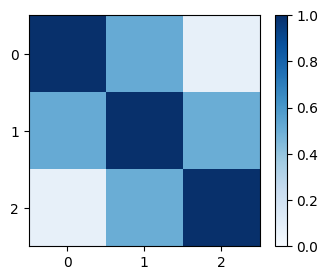

In [172]:
corr_matrix_infect_sum1_abs = np.abs(np.corrcoef(sim_infect_sum1, rowvar = False))
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_matrix_infect_sum1_abs, vmin=0, vmax=1, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(true_infect_sum1[0])))
ax.set_yticks(range(len(true_infect_sum1[0])))
plt.show()

Using Euclidean distances on normalized summary statistics

In [173]:
ss1_infect_mean = np.mean(sim_infect_sum1, axis = 0)
ss1_infect_std  = np.std(sim_infect_sum1, axis = 0)

sim_infect_sum1_norm  = (sim_infect_sum1 - ss1_infect_mean) / ss1_infect_std
true_infect_sum1_norm = (true_infect_sum1 - ss1_infect_mean) / ss1_infect_std

In [174]:
distance_infect_sum1 = np.linalg.norm(sim_infect_sum1_norm - true_infect_sum1_norm, axis = 1)
epsilon_infect_sum1  = np.quantile(distance_infect_sum1, epsilon_threshold)

accepted_beta_infect_sum1  = param_values[distance_infect_sum1 < epsilon_infect_sum1, 0]
accepted_gamma_infect_sum1 = param_values[distance_infect_sum1 < epsilon_infect_sum1, 1]
accepted_rho_infect_sum1   = param_values[distance_infect_sum1 < epsilon_infect_sum1, 2]

Using Mahalanobis Distances

In [175]:
cov_infect_sum1     = np.cov(sim_infect_sum1.T)
cov_inv_infect_sum1 = np.linalg.inv(cov_infect_sum1)

mahal_dist_infect_sum1    = np.array([mahalanobis(sim_row, true_infect_sum1[0], cov_inv_infect_sum1) for sim_row in sim_infect_sum1])
mahal_epsilon_infect_sum1 = np.quantile(mahal_dist_infect_sum1, epsilon_threshold)

mahal_accepted_beta_infect_sum1  = param_values[mahal_dist_infect_sum1 < mahal_epsilon_infect_sum1, 0]
mahal_accepted_gamma_infect_sum1 = param_values[mahal_dist_infect_sum1 < mahal_epsilon_infect_sum1, 1]
mahal_accepted_rho_infect_sum1   = param_values[mahal_dist_infect_sum1 < mahal_epsilon_infect_sum1, 2]

##### Rewire Count

In [176]:
def rewire_summary_1(rewire_sim):
    rewire_total     = np.sum(rewire_sim, axis = 1)
    rewire_peak_time = np.argmax(rewire_sim, axis = 1)
    rewire_zero_num  = np.sum(rewire_sim == 0, axis = 1)

    summary = [rewire_total, rewire_peak_time, rewire_zero_num] 
    return np.stack(summary, axis = 1)

In [177]:
sim_rewire_sum1  = rewire_summary_1(rewire_sim_1)
true_rewire_sum1 = rewire_summary_1(true_rewire_1[None, :])

In [178]:
ss1_rewire_mean = np.mean(sim_rewire_sum1, axis = 0)
ss1_rewire_std  = np.std(sim_rewire_sum1, axis = 0)

sim_rewire_sum1_norm  = (sim_rewire_sum1 - ss1_rewire_mean) / ss1_rewire_std
true_rewire_sum1_norm = (true_rewire_sum1 - ss1_rewire_mean) / ss1_rewire_std

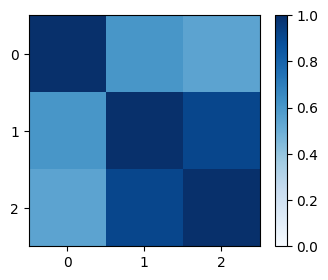

In [179]:
corr_matrix_rewire_sum1_abs = np.abs(np.corrcoef(sim_rewire_sum1, rowvar = False))
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_matrix_rewire_sum1_abs, vmin=0, vmax=1, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(true_rewire_sum1[0])))
ax.set_yticks(range(len(true_rewire_sum1[0])))
plt.show()

In [180]:
distance_rewire_sum1 = np.linalg.norm(sim_rewire_sum1_norm - true_rewire_sum1_norm, axis = 1)
epsilon_rewire_sum1  = np.quantile(distance_rewire_sum1, epsilon_threshold)

accepted_beta_rewire_sum1  = param_values[distance_rewire_sum1 < epsilon_rewire_sum1, 0]
accepted_gamma_rewire_sum1 = param_values[distance_rewire_sum1 < epsilon_rewire_sum1, 1]
accepted_rho_rewire_sum1   = param_values[distance_rewire_sum1 < epsilon_rewire_sum1, 2]

In [181]:
cov_rewire_sum1     = np.cov(sim_rewire_sum1.T)
cov_inv_rewire_sum1 = np.linalg.inv(cov_rewire_sum1)

mahal_dist_rewire_sum1    = np.array([mahalanobis(sim_row, true_rewire_sum1[0], cov_inv_rewire_sum1)
                                       for sim_row in sim_rewire_sum1])
mahal_epsilon_rewire_sum1 = np.quantile(mahal_dist_rewire_sum1, epsilon_threshold)

mahal_accepted_beta_rewire_sum1  = param_values[mahal_dist_rewire_sum1 < mahal_epsilon_rewire_sum1, 0]
mahal_accepted_gamma_rewire_sum1 = param_values[mahal_dist_rewire_sum1 < mahal_epsilon_rewire_sum1, 1]
mahal_accepted_rho_rewire_sum1   = param_values[mahal_dist_rewire_sum1 < mahal_epsilon_rewire_sum1, 2]

In [182]:
def degree_summary_1(degree_sim):
    x = np.arange(31)

    prop_low   = np.sum(degree_sim[:, 0:4], axis = 1) / 200
    prop_above = np.sum(degree_sim[:, 11:], axis = 1) / 200

    mean_degree = np.sum(x * degree_sim, axis = 1) / 200
    var_degree  = np.sum(degree_sim * (x - mean_degree[:, None]) ** 2, axis = 1) / 200

    summary = [prop_low, prop_above, mean_degree, var_degree]
    return np.stack(summary, axis = 1)

In [183]:
sim_degree_sum1  = degree_summary_1(degree_sim_1)
true_degree_sum1 = degree_summary_1(true_degree_1[None, :])

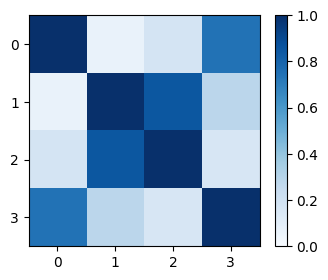

In [184]:
corr_matrix_sum1_abs = np.abs(np.corrcoef(sim_degree_sum1, rowvar = False))
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr_matrix_sum1_abs, vmin=0, vmax=1, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(true_degree_sum1[0])))
ax.set_yticks(range(len(true_degree_sum1[0])))
plt.show()

In [185]:
ss1_degree_mean = np.mean(sim_degree_sum1, axis = 0)
ss1_degree_std  = np.std(sim_degree_sum1, axis = 0)

sim_degree_sum1_norm  = (sim_degree_sum1 - ss1_degree_mean) / ss1_degree_std
true_degree_sum1_norm = (true_degree_sum1 - ss1_degree_mean) / ss1_degree_std

In [186]:
distance_degree_sum1 = np.linalg.norm(sim_degree_sum1_norm - true_degree_sum1_norm, axis = 1)
epsilon_degree_sum1  = np.quantile(distance_degree_sum1, epsilon_threshold)

accepted_beta_degree_sum1  = param_values[distance_degree_sum1 < epsilon_degree_sum1, 0]
accepted_gamma_degree_sum1 = param_values[distance_degree_sum1 < epsilon_degree_sum1, 1]
accepted_rho_degree_sum1   = param_values[distance_degree_sum1 < epsilon_degree_sum1, 2]

In [187]:
cov_degree_sum1     = np.cov(sim_degree_sum1.T)
cov_inv_degree_sum1 = np.linalg.inv(cov_degree_sum1)

mahal_dist_degree_sum1    = np.array([mahalanobis(sim_row, true_degree_sum1[0], cov_inv_degree_sum1) 
                                      for sim_row in sim_degree_sum1])
mahal_epsilon_degree_sum1 = np.quantile(mahal_dist_degree_sum1, epsilon_threshold)

mahal_accepted_beta_degree_sum1  = param_values[mahal_dist_degree_sum1 < mahal_epsilon_degree_sum1, 0]
mahal_accepted_gamma_degree_sum1 = param_values[mahal_dist_degree_sum1 < mahal_epsilon_degree_sum1, 1]
mahal_accepted_rho_degree_sum1   = param_values[mahal_dist_degree_sum1 < mahal_epsilon_degree_sum1, 2]

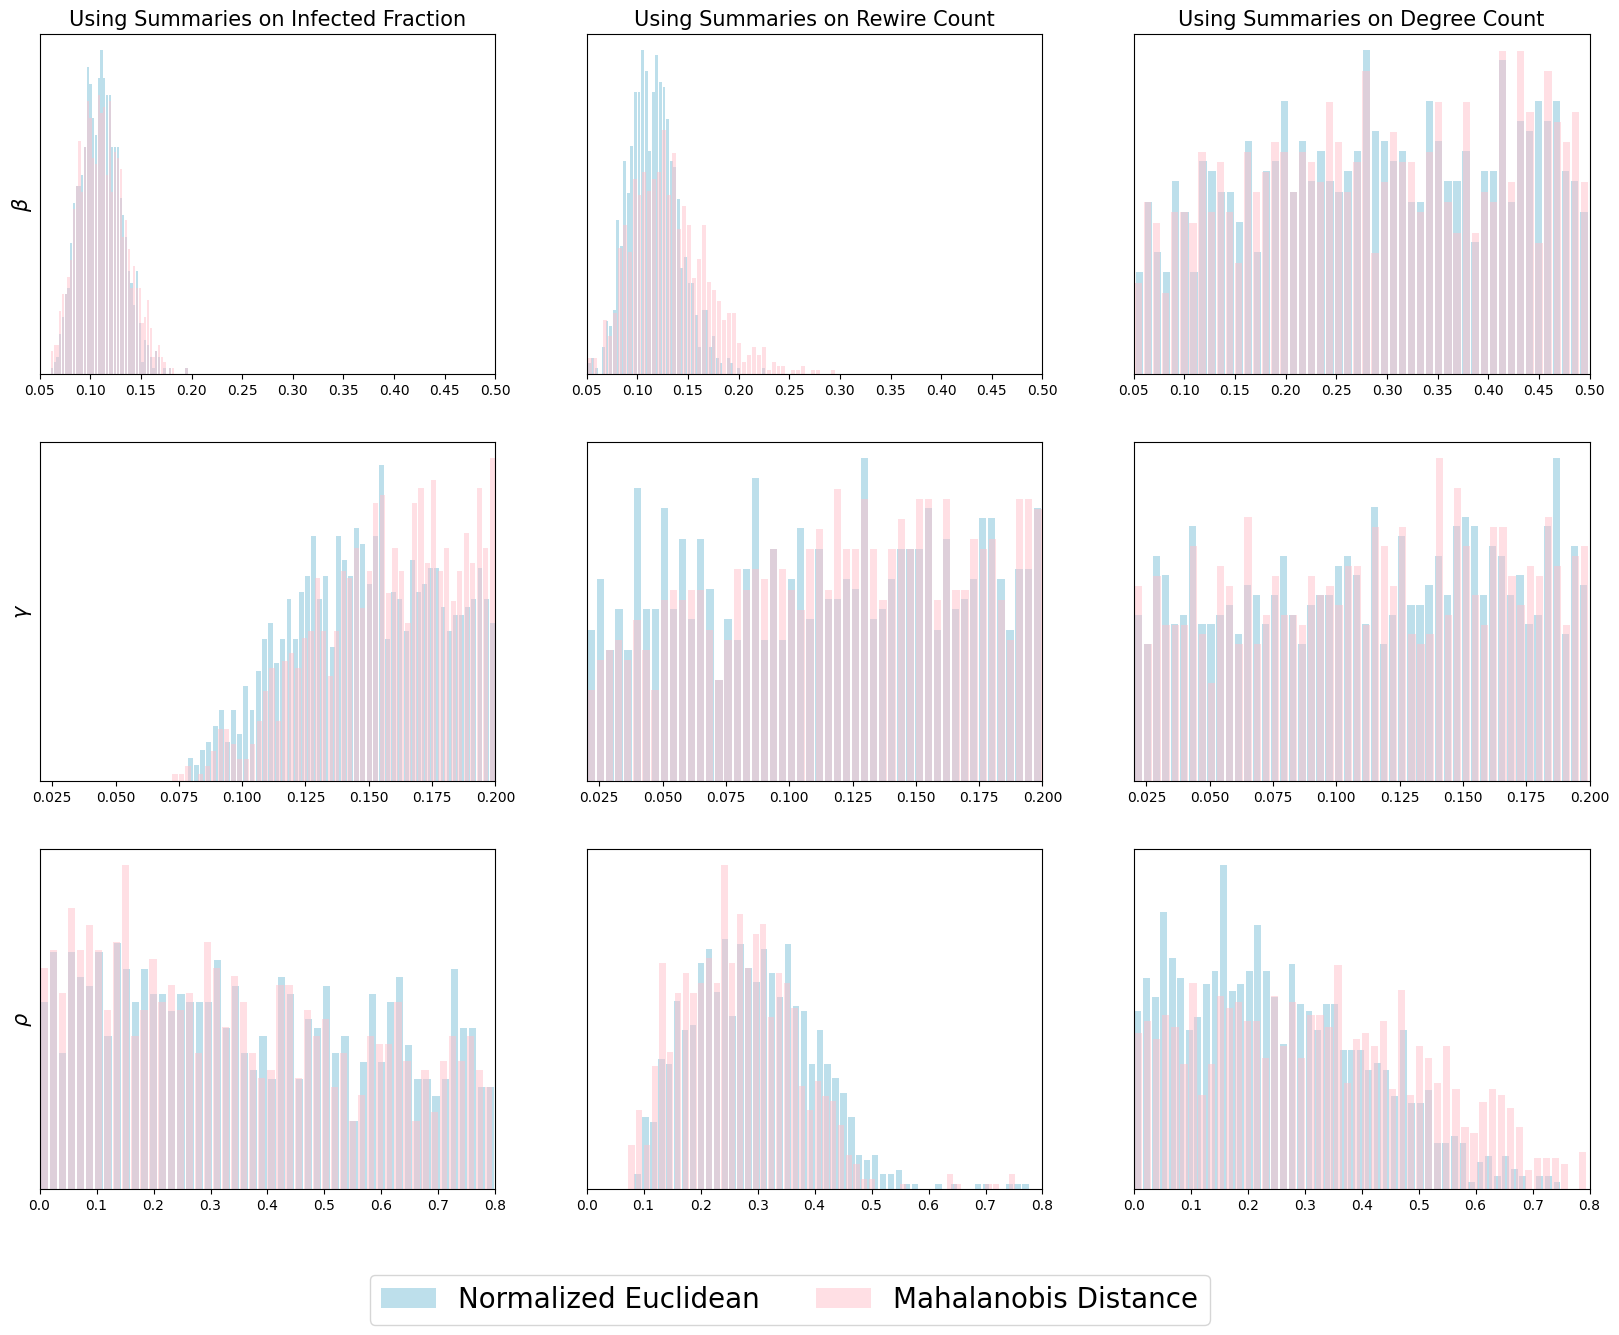

In [188]:
fig, axs = plt.subplots(3, 3, figsize = (20, 15))

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]
ax13 = axs[0][2]
ax23 = axs[1][2]
ax33 = axs[2][2]

ax11.set_title("Using Summaries on Infected Fraction", fontsize = 15)
ax12.set_title("Using Summaries on Rewire Count", fontsize = 15)
ax13.set_title("Using Summaries on Degree Count", fontsize = 15)

for p_idx in range(3):
    for s_idx in range(3):
        ax = axs[p_idx, s_idx]
        ax.set_yticks([])

ax11.hist(accepted_beta_infect_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax11.hist(mahal_accepted_beta_infect_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax11.set_xlim(0.05, 0.5)
ax11.set_ylabel(r'$\beta$', fontsize = 15)
ax21.hist(accepted_gamma_infect_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax21.hist(mahal_accepted_gamma_infect_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax21.set_xlim(0.02, 0.2)
ax21.set_ylabel(r'$\gamma$', fontsize = 15)
ax31.hist(accepted_rho_infect_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax31.hist(mahal_accepted_rho_infect_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax31.set_xlim(0, 0.8)
ax31.set_ylabel(r'$\rho$', fontsize = 15)

ax12.hist(accepted_beta_rewire_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax12.hist(mahal_accepted_beta_rewire_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax12.set_xlim(0.05, 0.5)
ax22.hist(accepted_gamma_rewire_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax22.hist(mahal_accepted_gamma_rewire_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax22.set_xlim(0.02, 0.2)
ax32.hist(accepted_rho_rewire_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax32.hist(mahal_accepted_rho_rewire_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax32.set_xlim(0, 0.8)

ax13.hist(accepted_beta_degree_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax13.hist(mahal_accepted_beta_degree_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax13.set_xlim(0.05, 0.5)
ax23.hist(accepted_gamma_degree_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax23.hist(mahal_accepted_gamma_degree_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax23.set_xlim(0.02, 0.2)
ax33.hist(accepted_rho_degree_sum1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax33.hist(mahal_accepted_rho_degree_sum1, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax33.set_xlim(0, 0.8)

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, 0.01), fontsize = 20)
plt.show()

### Summary #2
Using all 3 distributions

In [189]:
# Same function as infect_summary_1 just renamed 
def infect_summary_2(infected_sim):
    infect_mean = np.mean(infected_sim, axis = 1)
    infect_peak = np.max(infected_sim, axis = 1)

    # Summary not used due to high correlation
    # infect_peak_time = np.argmax(infected_sim, axis = 1)

    summary = [infect_mean, infect_peak] 
    return np.stack(summary, axis = 1)

def rewire_summary_2(rewire_sim):
    rewire_total = np.sum(rewire_sim, axis = 1)
    rewire_peak_time = np.argmax(rewire_sim, axis = 1)

    # Summary not used due to high correlation
    # rewire_zero_num = np.sum(rewire_sim == 0, axis = 1)

    summary = [rewire_total, rewire_peak_time] 
    return np.stack(summary, axis = 1)

# def degree_summary_2(degree_sim):
#     bins = np.arange(0, 31)
#     proportions = degree_sim / np.sum(degree_sim, axis = 1, keepdims = True)
#     degree_mean = np.sum(bins* proportions, axis = 1)
#     degree_variance = np.sum((proportions * (bins - degree_mean[:, None]) ** 2), axis = 1)
#     degree_std    = np.sqrt(degree_variance)                                                                        # (N,)
#     kurtosis_degree = (proportions * ((bins - degree_mean[:, None]) / degree_std[:, None]) ** 4).sum(axis=1)            # (N,)
#     kurtosis_degree = np.where(degree_std > 0, kurtosis_degree, 0.0)
#     summary = [degree_mean, degree_variance, kurtosis_degree]
#     return np.stack(summary, axis = 1)

def degree_summary_2(degree_sim):
    x = np.arange(31)

    prop_low   = np.sum(degree_sim[:, 0:4], axis = 1) / 200
    prop_above = np.sum(degree_sim[:, 11:], axis = 1) / 200

    mean_degree = np.sum(x * degree_sim, axis = 1) / 200
    var_degree  = np.sum(degree_sim * (x - mean_degree[:, None]) ** 2, axis = 1) / 200

    summary = [prop_low, prop_above, mean_degree, var_degree]
    summary = [prop_above, var_degree]
    return np.stack(summary, axis = 1)

In [190]:
infect_sim_sum2  = infect_summary_2(infected_sim_1) 
infect_true_sum2 = infect_summary_2(true_infected_1[None, :])

rewire_sim_sum2  = rewire_summary_2(rewire_sim_1)
rewire_true_sum2 = rewire_summary_2(true_rewire_1[None, :])

degree_sim_sum2  = degree_summary_2(degree_sim_1)
degree_true_sum2 = degree_summary_2(true_degree_1[None, :])

# sim_sum2 = np.hstack([infect_sim_sum2, rewire_sim_sum2, degree_sim_sum2])
# true_sum2 = np.hstack([infect_true_sum2, rewire_true_sum2, degree_true_sum2])

# Using the first 2 distributions summaries only

sim_sum2  = np.hstack([infect_sim_sum2, rewire_sim_sum2])
true_sum2 = np.hstack([infect_true_sum2, rewire_true_sum2])

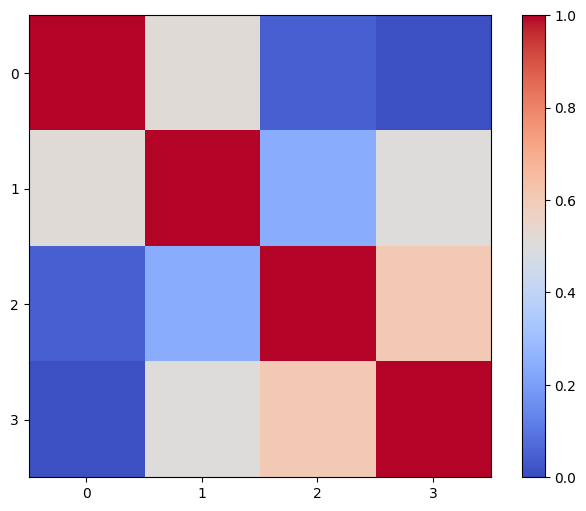

In [191]:
corr_matrix_sum2_abs = np.abs(np.corrcoef(sim_sum2, rowvar = False))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix_sum2_abs, vmin=0, vmax=1, cmap='coolwarm')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(true_sum2[0])))
ax.set_yticks(range(len(true_sum2[0])))
plt.show()

In [192]:
ss2_mean = np.mean(sim_sum2, axis = 0)
ss2_std  = np.std(sim_sum2, axis = 0)

sim_sum2_norm  = (sim_sum2 - ss2_mean) / ss2_std
true_sum2_norm = (true_sum2 - ss2_mean) / ss2_std

In [193]:
distance_sum2 = np.linalg.norm(sim_sum2_norm - true_sum2_norm, axis = 1)
epsilon_sum2  = np.quantile(distance_sum2, epsilon_threshold)

accepted_beta_sum2  = param_values[distance_sum2 < epsilon_sum2, 0]
accepted_gamma_sum2 = param_values[distance_sum2 < epsilon_sum2, 1]
accepted_rho_sum2   = param_values[distance_sum2 < epsilon_sum2, 2]

In [194]:
cov_sum2     = np.cov(sim_sum2.T)
cov_inv_sum2 = np.linalg.inv(cov_sum2)

mahal_dist_sum2    = np.array([mahalanobis(sim_row, true_sum2[0], cov_inv_sum2) 
                               for sim_row in sim_sum2])
mahal_epsilon_sum2 = np.quantile(mahal_dist_sum2, epsilon_threshold)

mahal_accepted_beta_sum2  = param_values[mahal_dist_sum2 < mahal_epsilon_sum2, 0]
mahal_accepted_gamma_sum2 = param_values[mahal_dist_sum2 < mahal_epsilon_sum2, 1]
mahal_accepted_rho_sum2   = param_values[mahal_dist_sum2 < mahal_epsilon_sum2, 2]


Using summary statistics that takes in multiple distributions (intentionally correlated) 

In [195]:
def corr_summaries(infected_sim, rewire_sim, degree_sim):
    
    def pearson_corr(A, B):
        A_centered = A - np.mean(A, axis = 1, keepdims = True)
        B_centered = B - np.mean(B, axis = 1, keepdims = True)
        
        num   = np.sum(A_centered * B_centered, axis = 1)
        denom = np.sqrt(np.sum(A_centered ** 2, axis = 1) * np.sum(B_centered ** 2, axis = 1))

        corr = np.where(denom > 1e-10, num / denom, 0.0)
        return corr
    
    corr_infected_rewire = pearson_corr(infected_sim, rewire_sim) 

    degree_mean  = np.sum(degree_sim * np.arange(31), axis = 1) / 200
    rewire_total = np.sum(rewire_sim, axis = 1)
    ratio_rewire_degree = rewire_total / degree_mean 

    degree_prop          = np.sum(degree_sim[:, 0:4], axis = 1) / 200
    prod_infected_degree = np.max(infected_sim, axis = 1) * degree_prop

    denom   = np.max(infected_sim, axis = 1) * degree_mean 
    denom_0 = np.where(denom > 1e-10, denom, 0)
    infected_rewire_degree = (np.max(rewire_sim, axis = 1) / denom_0) 

    sum2 = [corr_infected_rewire, ratio_rewire_degree, prod_infected_degree, infected_rewire_degree]
    return np.stack(sum2, axis = 1)
 

In [196]:
corr_sim_sum2  = corr_summaries(infected_sim_1, rewire_sim_1, degree_sim_1)
corr_true_sum2 = corr_summaries(true_infected_1[None, :], true_rewire_1[None, :], true_degree_1[None, :])

sim_sum2  = np.hstack([infect_sim_sum2, rewire_sim_sum2, corr_sim_sum2])
true_sum2 = np.hstack([infect_true_sum2, rewire_true_sum2, corr_true_sum2])

C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\4186630402.py:10: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)


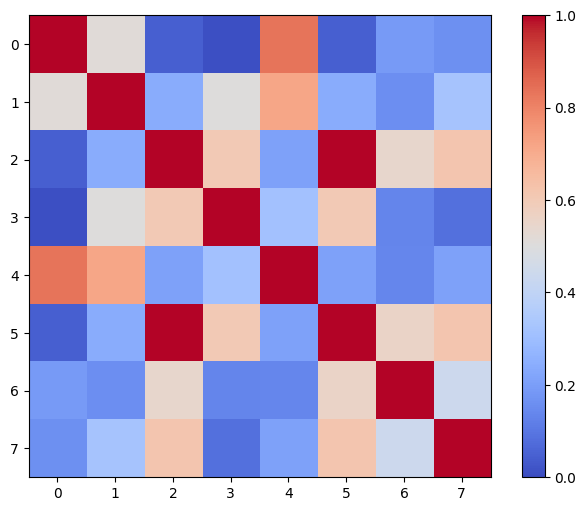

In [197]:
corr_matrix_sum2_abs = np.abs(np.corrcoef(sim_sum2, rowvar = False))
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix_sum2_abs, vmin=0, vmax=1, cmap='coolwarm')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(true_sum2[0])))
ax.set_yticks(range(len(true_sum2[0])))
plt.show()

In [198]:
ss2_mean = np.mean(sim_sum2, axis = 0)
ss2_std  = np.std(sim_sum2, axis = 0)

sim_sum2_norm  = (sim_sum2 - ss2_mean) / ss2_std
true_sum2_norm = (true_sum2 - ss2_mean) / ss2_std

In [199]:
distance_sum2 = np.linalg.norm(sim_sum2_norm - true_sum2_norm, axis = 1)
epsilon_sum2  = np.quantile(distance_sum2, epsilon_threshold)

accepted_beta_sum2  = param_values[distance_sum2 < epsilon_sum2, 0]
accepted_gamma_sum2 = param_values[distance_sum2 < epsilon_sum2, 1]
accepted_rho_sum2   = param_values[distance_sum2 < epsilon_sum2, 2]

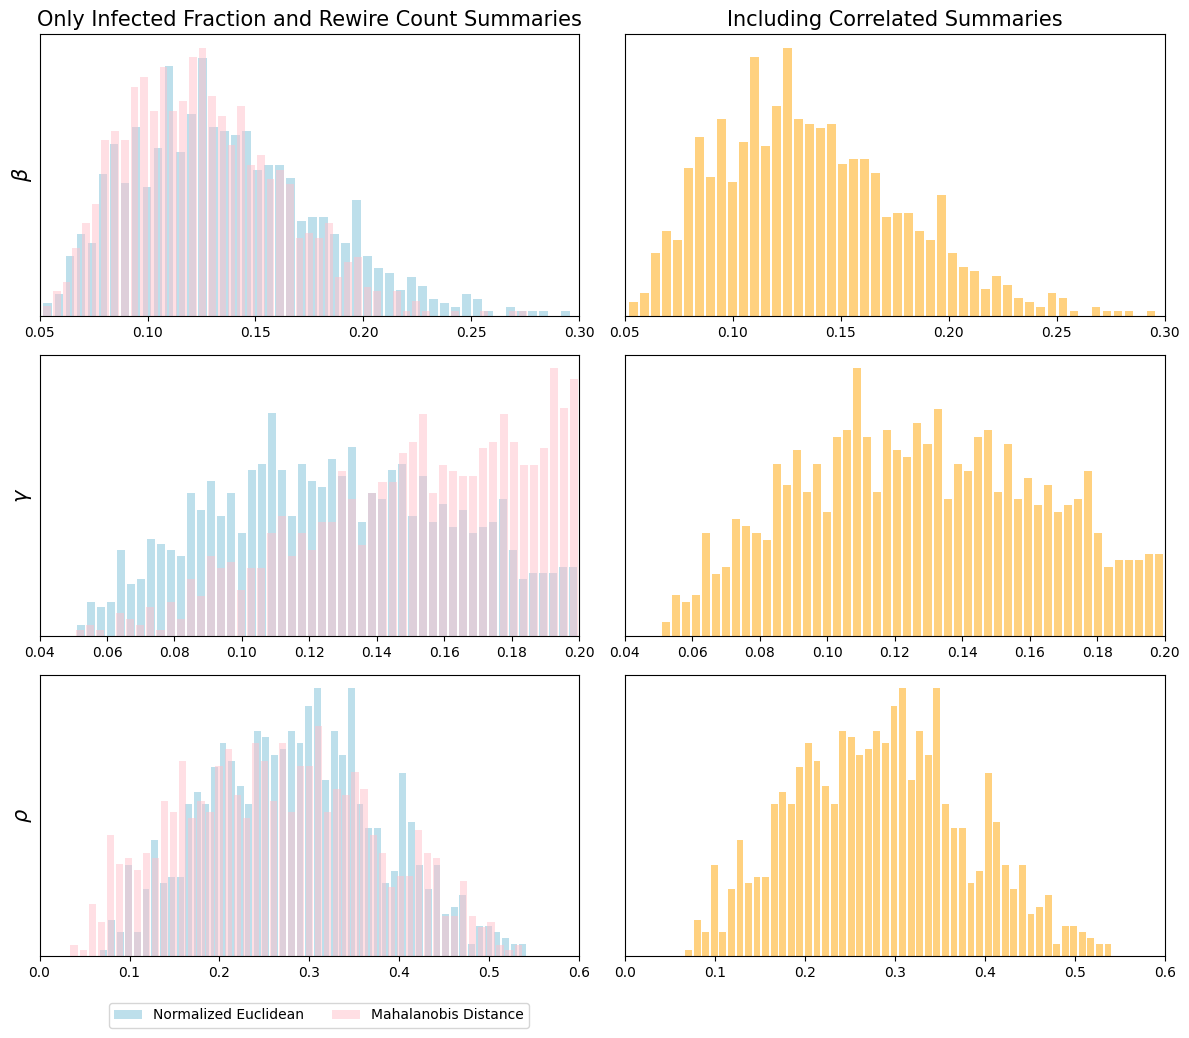

In [200]:
fig, axs = plt.subplots(3, 2, figsize = (12, 10))

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]

ax11.set_title("Only Infected Fraction and Rewire Count Summaries", fontsize = 15)
ax12.set_title("Including Correlated Summaries", fontsize = 15) 

ax11.hist(accepted_beta_sum2, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax11.hist(mahal_accepted_beta_sum2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax12.hist(accepted_beta_sum2, bins = 50, color = "orange", alpha = 0.5, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax11.set_ylabel(r'$\beta$', fontsize = 15)
ax11.set_xlim(0.05, 0.3)
ax12.set_xlim(0.05, 0.3)
ax21.hist(accepted_gamma_sum2, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax21.hist(mahal_accepted_gamma_sum2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax22.hist(accepted_gamma_sum2, bins = 50, color = "orange", alpha = 0.5, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax21.set_ylabel(r'$\gamma$', fontsize = 15)
ax21.set_xlim(0.04, 0.2)
ax22.set_xlim(0.04, 0.2)
ax31.hist(accepted_rho_sum2, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax31.hist(mahal_accepted_rho_sum2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Mahalanobis Distance")
ax32.hist(accepted_rho_sum2, bins = 50, color = "orange", alpha = 0.5, rwidth = 0.8, density = True, label = "Normalized Euclidean")
ax31.set_ylabel(r'$\rho$', fontsize = 15)
ax31.set_xlim(0, 0.6)
ax32.set_xlim(0, 0.6)

for p_idx in range(3):
    for s_idx in range(2):
        ax = axs[p_idx, s_idx]
        ax.set_yticks([])

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.27, -0.04))
plt.tight_layout()
plt.show()

### Summary #3

Using realisations

In [201]:
def sum3(infected_sim, rewire_sim, degree_sim):

    infect_mean = np.mean(infected_sim, axis = 2)
    infect_peak = np.max(infected_sim, axis = 2)

    rewire_total     = np.sum(rewire_sim, axis = 2)
    rewire_peak_time = np.argmax(rewire_sim, axis = 2)

    def pearson_corr(A, B):
        A_centered = A - np.mean(A, axis = 2, keepdims = True)
        B_centered = B - np.mean(B, axis = 2, keepdims = True)

        num   = np.sum(A_centered * B_centered, axis = 2)
        denom = np.sqrt(np.sum(A_centered ** 2, axis = 2) * np.sum(B_centered ** 2, axis = 2))

        corr = np.where(denom > 1e-10, num / denom, 0.0)
        return corr
    
    corr_infected_rewire = pearson_corr(infected_sim, rewire_sim) 

    degree_mean       = np.sum(degree_sim * np.arange(31), axis = 2) / 200
    rewire_total_corr = np.sum(rewire_sim, axis = 2)
    ratio_rewire_degree = rewire_total_corr / degree_mean

    degree_prop          = np.sum(degree_sim[:, :, 0:4], axis = 2) / 200
    prod_infected_degree = np.max(infected_sim, axis = 2) * degree_prop

    denom   = np.max(infected_sim, axis = 2) * degree_mean 
    denom_0 = np.where(denom > 1e-10, denom, 0)
    infected_rewire_degree = (np.max(rewire_sim, axis = 2) / denom_0)

    sum3 = [infect_mean, infect_peak, rewire_total, rewire_peak_time, corr_infected_rewire, ratio_rewire_degree, prod_infected_degree, infected_rewire_degree]
    return np.stack(sum3, axis = 2)

In [202]:
sim_big_sum3  = sum3(infected_sim, rewire_sim, degree_sim)
true_big_sum3 = sum3(true_infected[None, :], true_rewire[None, :], true_degree[None, :])

C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)


Using Average Summaries

In [203]:
sim_sum3_1  = np.mean(sim_big_sum3, axis = 1)
true_sum3_1 = np.mean(true_big_sum3, axis = 1) 

In [204]:
ss3_mean_1 = np.mean(sim_sum3_1, axis = 0)
ss3_std_1  = np.std(sim_sum3_1, axis = 0)

sim_sum3_norm_1  = (sim_sum3_1 - ss3_mean_1) / ss3_std_1
true_sum3_norm_1 = (true_sum3_1 - ss3_mean_1) / ss3_std_1

In [205]:
distance_sum3_1 = np.linalg.norm(sim_sum3_norm_1 - true_sum3_norm_1, axis = 1)
epsilon_sum3_1  = np.quantile(distance_sum3_1, epsilon_threshold)

accepted_beta_sum3_1  = param_values[distance_sum3_1 < epsilon_sum3_1, 0]
accepted_gamma_sum3_1 = param_values[distance_sum3_1 < epsilon_sum3_1, 1]
accepted_rho_sum3_1   = param_values[distance_sum3_1 < epsilon_sum3_1, 2]

Using Median Distance

In [206]:
sim_sum3_big_norm  = (sim_big_sum3 - ss3_mean_1) / ss3_std_1
true_sum3_big_norm = (true_big_sum3 - ss3_mean_1) / ss3_std_1

sim_sum3_norm_2  = np.median(sim_sum3_big_norm, axis = 1)
true_sum3_norm_2 = np.median(true_sum3_big_norm, axis = 1)

In [207]:
distance_sum3_2 = np.linalg.norm(sim_sum3_norm_2 - true_sum3_norm_2, axis = 1)
epsilon_sum3_2  = np.quantile(distance_sum3_2, epsilon_threshold)

accepted_beta_sum3_2  = param_values[distance_sum3_2 < epsilon_sum3_2, 0]
accepted_gamma_sum3_2 = param_values[distance_sum3_2 < epsilon_sum3_2, 1]
accepted_rho_sum3_2   = param_values[distance_sum3_2 < epsilon_sum3_2, 2]

In [208]:
S = 1000

sum3_var = np.var(sim_big_sum3, axis = 1)

idx = np.random.choice(10000, size = S, replace = False)

sum3_var_sample = sum3_var[idx, :]
param_sample    = param_values[idx, :]

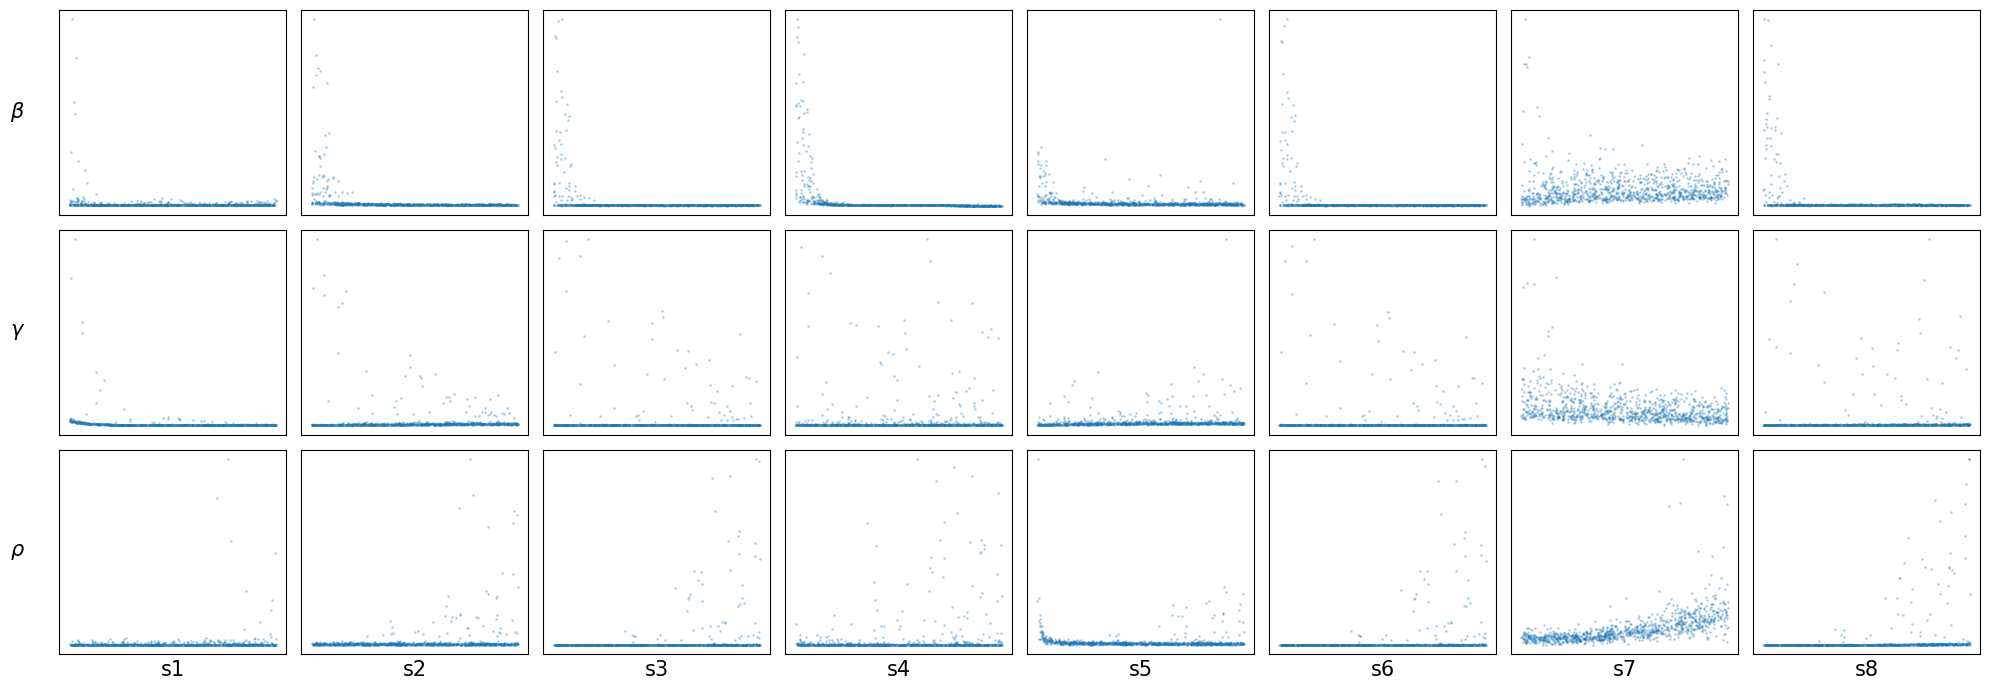

In [209]:
fig, axs = plt.subplots(3, 8, figsize=(20, 7))

param_names   = [r'$\beta$', r'$\gamma$', r'$\rho$']
summary_names = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8']
for p_idx in range(3):
    for s_idx in range(8):
        ax = axs[p_idx, s_idx]
        ax.scatter(param_sample[:, p_idx], sum3_var_sample[:, s_idx], alpha=0.25, s=1)
        ax.set_xticks([])
        ax.set_yticks([])

for p_idx, name in enumerate(param_names):
    axs[p_idx, 0].set_ylabel(name, fontsize=15, rotation=0, labelpad=30, va='center')

for s_idx, name in enumerate(summary_names):
    axs[2, s_idx].set_xlabel(name, fontsize=15)

plt.tight_layout()
plt.show()

In [210]:
sim_sum3_3  = np.column_stack([sim_sum3_1, sum3_var[:, 6]])
true_sum3_3 = np.column_stack([true_sum3_1, np.var(true_big_sum3, axis = 1)[:, 6]])

In [211]:
ss3_mean_3 = np.mean(sim_sum3_3, axis = 0)
ss3_std_3  = np.std(sim_sum3_3, axis = 0)

sim_sum3_norm_3  = (sim_sum3_3 - ss3_mean_3) / ss3_std_3
true_sum3_norm_3 = (true_sum3_3 - ss3_mean_3) / ss3_std_3

In [212]:
distance_sum3_3 = np.linalg.norm(sim_sum3_norm_3 - true_sum3_norm_3, axis = 1)
epsilon_sum3_3  = np.quantile(distance_sum3_3, epsilon_threshold)

accepted_beta_sum3_3  = param_values[distance_sum3_3 < epsilon_sum3_3, 0]
accepted_gamma_sum3_3 = param_values[distance_sum3_3 < epsilon_sum3_3, 1]
accepted_rho_sum3_3   = param_values[distance_sum3_3 < epsilon_sum3_3, 2]

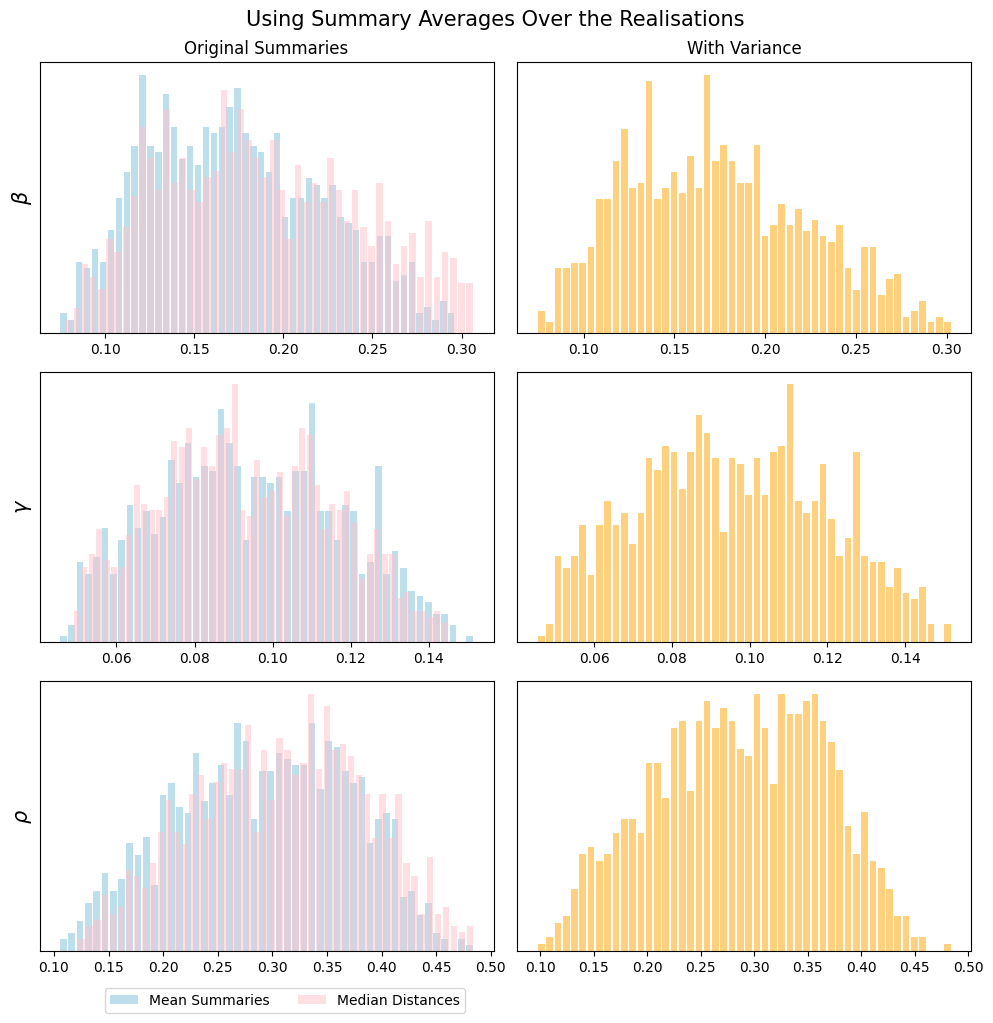

In [213]:
fig, axs = plt.subplots(3, 2, figsize = (10, 10))
fig.suptitle("Using Summary Averages Over the Realisations", fontsize = 15)

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]

ax11.set_title("Original Summaries")
ax12.set_title("With Variance")

ax11.hist(accepted_beta_sum3_1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Mean Summaries")
ax11.hist(accepted_beta_sum3_2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Median Distances")
ax11.set_ylabel(r'$\beta$', fontsize = 15)
ax21.hist(accepted_gamma_sum3_1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Average Summary -> Distance")
ax21.hist(accepted_gamma_sum3_2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Summary -> Median Distance")
ax21.set_ylabel(r'$\gamma$', fontsize = 15)
ax31.hist(accepted_rho_sum3_1, bins = 50, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Average Summary -> Distance")
ax31.hist(accepted_rho_sum3_2, bins = 50, color = "pink", alpha = 0.5,  rwidth = 0.8, density = True, label = "Summary -> Median Distance")
ax31.set_ylabel(r'$\rho$', fontsize = 15)
ax12.hist(accepted_beta_sum3_3, bins = 50, color = "orange", alpha = 0.5,  rwidth = 0.8, density = True, label = "Using Variance of Summary")
ax22.hist(accepted_gamma_sum3_3, bins = 50, color = "orange", alpha = 0.5,  rwidth = 0.8, density = True, label = "Using Variance of Summary")
ax32.hist(accepted_rho_sum3_3, bins = 50, color = "orange", alpha = 0.5,  rwidth = 0.8, density = True, label = "Using Variance of Summary")

handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.29, -0.03), fontsize = 10)

for p_idx in range(3):
    for s_idx in range(2):
        ax = axs[p_idx, s_idx]
        ax.set_yticks([])

plt.tight_layout()
plt.show()

### Summary 4

Due to a small number of simulations being used, $(10000)$, tolerance bias is likely higher, and using regression adjustment seems applicable. 

In [214]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

In [215]:
epsilon_threshold = 0.1

In [216]:
distance_sum4_1 = np.linalg.norm(sim_sum3_norm_3 - true_sum3_norm_3, axis = 1)
epsilon_sum4_1  = np.quantile(distance_sum4_1, epsilon_threshold)

accepted_beta_sum4_1  = param_values[distance_sum4_1 < epsilon_sum4_1, 0]
accepted_gamma_sum4_1 = param_values[distance_sum4_1 < epsilon_sum4_1, 1]
accepted_rho_sum4_1   = param_values[distance_sum4_1 < epsilon_sum4_1, 2]

In [217]:
regression_residuals = sim_sum3_norm_3 - true_sum3_norm_3

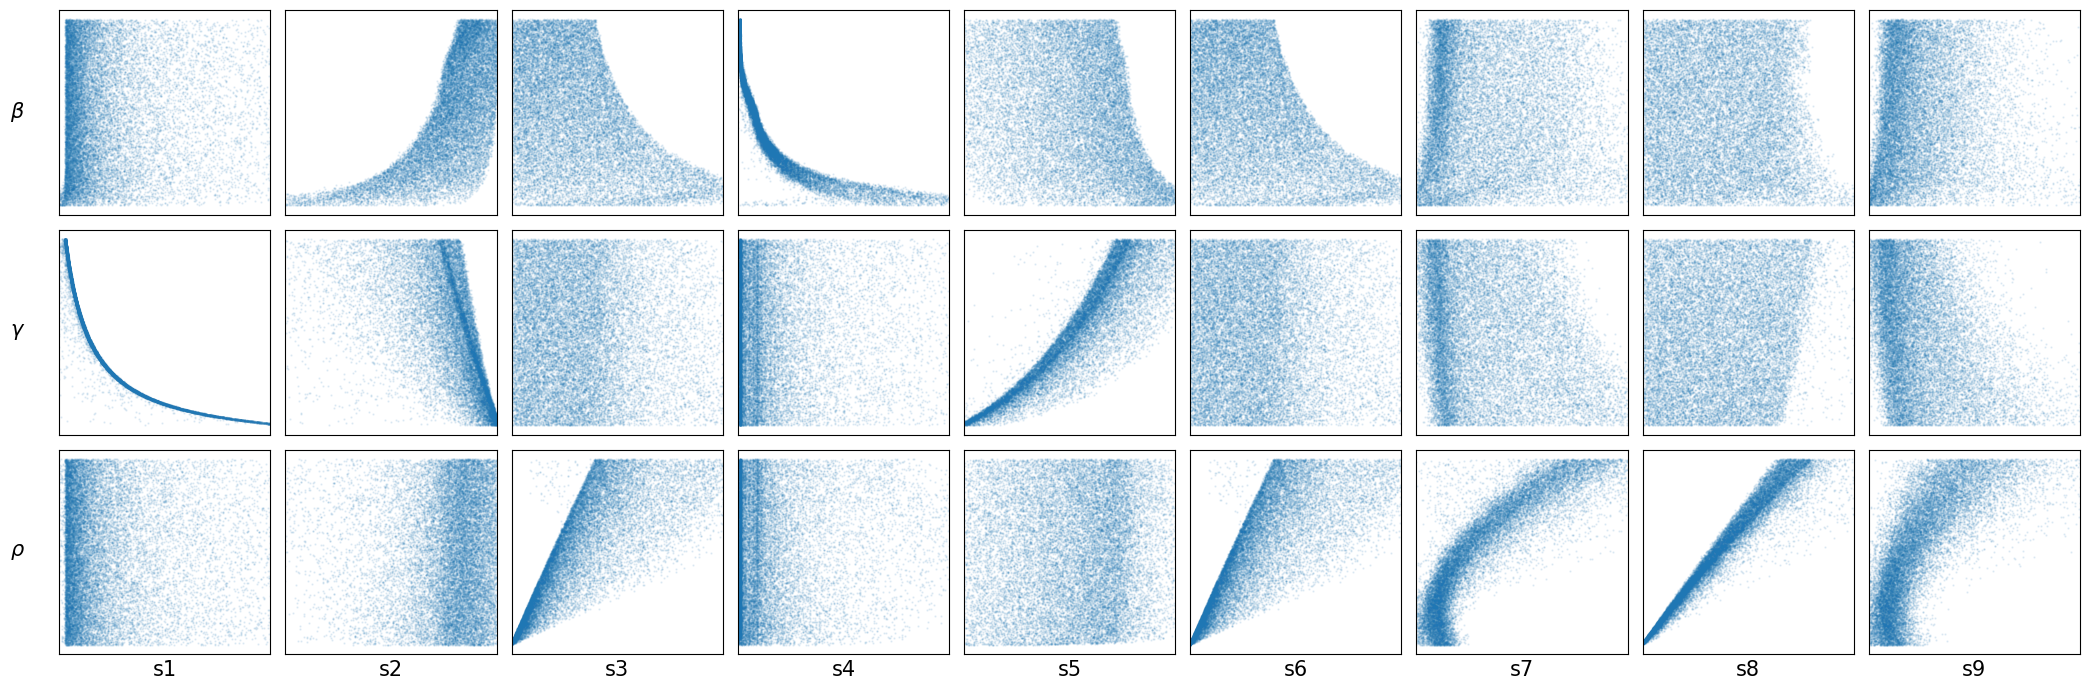

In [218]:
fig, axs = plt.subplots(3, 9, figsize = (21, 7))

param_names   = [r'$\beta$', r'$\gamma$', r'$\rho$']
summary_names = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9']

for p_idx in range(3):
    for s_idx in range(9):
        ax = axs[p_idx, s_idx]
        ax.scatter(regression_residuals[:, s_idx], param_values[:, p_idx], alpha=0.1, s=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        low  = np.percentile(regression_residuals[:, s_idx], 1)
        high = np.percentile(regression_residuals[:, s_idx], 99)
        ax.set_xlim(low, high)
        
# Parameter names on the left
for p_idx, name in enumerate(param_names):
    axs[p_idx, 0].set_ylabel(name, fontsize=15, rotation=0, labelpad=30, va='center')

# Summary names on the bottom
for s_idx, name in enumerate(summary_names):
    axs[2, s_idx].set_xlabel(name, fontsize=15)

plt.tight_layout()
plt.show()

In [219]:
summary_selection_linear = {
    0 : [],
    1: [],
    2: [2, 5, 7]
}

accepted_residuals = regression_residuals[distance_sum4_1 < epsilon_sum4_1] 
adjusted_params_linear = param_values[distance_sum4_1 < epsilon_sum4_1].copy()

for p_idx, selected in summary_selection_linear.items():
    if len(selected) == 0:
        continue

    X = accepted_residuals[:, selected]
    y = param_values[distance_sum4_1 < epsilon_sum4_1, p_idx]

    reg = LinearRegression().fit(X, y)

    adjustment = reg.predict(X) - reg.predict(np.zeros((1, len(selected))))
    adjusted_params_linear[:, p_idx] -= adjustment

    r2 = r2_score(y, reg.predict(X))
    print(f'Parameter {p_idx}: R²={r2:.3f} '
          f'(linear summaries={selected}')


Parameter 2: R²=0.966 (linear summaries=[2, 5, 7]


In [220]:
summary_selection_linear    = {0: [],      1: [],       2: [2, 5, 7]}
summary_selection_quadratic = {0: [3],      1: [0, 4],       2: []}

adjusted_params_both = param_values[distance_sum4_1 < epsilon_sum4_1].copy()

for p_idx in range(3):
    lin_idx  = summary_selection_linear[p_idx]
    quad_idx = summary_selection_quadratic[p_idx]

    if len(lin_idx) == 0 and len(quad_idx) == 0:
        continue

    parts, parts_zero = [], []

    if len(lin_idx) > 0:
        parts.append(accepted_residuals[:, lin_idx])
        parts_zero.append(np.zeros((1, len(lin_idx))))

    if len(quad_idx) > 0:
        pf = PolynomialFeatures(degree=2, include_bias=False)
        parts.append(pf.fit_transform(accepted_residuals[:, quad_idx]))
        parts_zero.append(pf.transform(np.zeros((1, len(quad_idx)))))

    X      = np.hstack(parts)
    X_zero = np.hstack(parts_zero)

    y   = param_values[distance_sum4_1 < epsilon_sum4_1, p_idx]
    reg = LinearRegression().fit(X, y)

    r2 = r2_score(y, reg.predict(X))
    print(f'Parameter {p_idx}: R²={r2:.3f} '
          f'(linear summaries={lin_idx}, quadratic summaries={quad_idx})')
    
    adjustment = reg.predict(X) - reg.predict(X_zero)
    adjusted_params_both[:, p_idx] -= adjustment

Parameter 0: R²=0.962 (linear summaries=[], quadratic summaries=[3])
Parameter 1: R²=0.990 (linear summaries=[], quadratic summaries=[0, 4])
Parameter 2: R²=0.966 (linear summaries=[2, 5, 7], quadratic summaries=[])


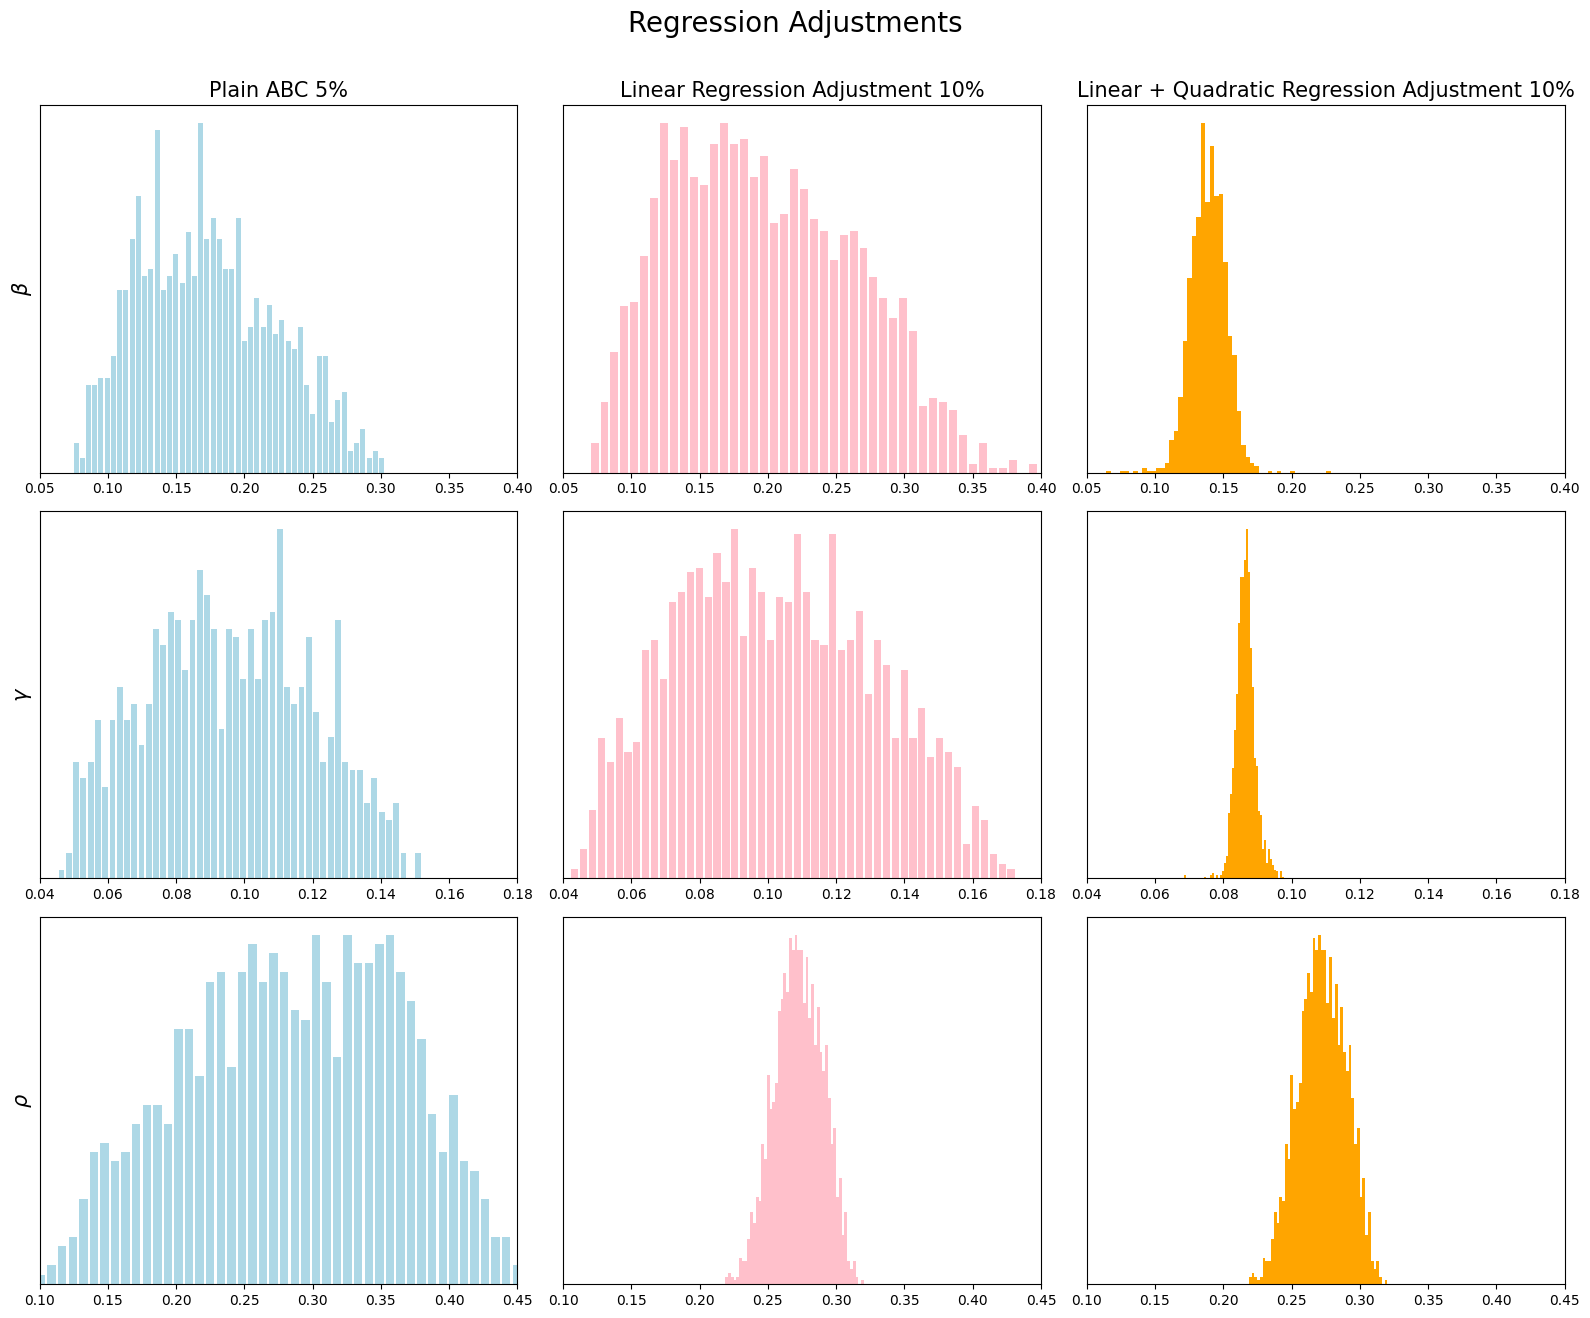

In [221]:
fig, axs = plt.subplots(3, 3, figsize = (16, 13))
fig.suptitle("Regression Adjustments", fontsize = 20, y = 1.01)

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]
ax13 = axs[0][2]
ax23 = axs[1][2]
ax33 = axs[2][2]

ax11.set_title("Plain ABC 5%", fontsize = 15)
ax12.set_title("Linear Regression Adjustment 10%", fontsize = 15)
ax13.set_title("Linear + Quadratic Regression Adjustment 10%", fontsize = 15)

ax11.hist(accepted_beta_sum3_3, bins = 50, color = "lightblue", alpha = 1,  rwidth = 0.8, density = True, label = "Plain 5%")
ax11.set_xlim(0.05, 0.4)
ax12.hist(adjusted_params_linear[:, 0], bins = 50, color = "pink", alpha = 1,  rwidth = 0.8, density = True, label = "Regression Adjusted 10%")
ax12.set_xlim(0.05, 0.4)
ax13.hist(adjusted_params_both[:, 0], bins = 50, color = "orange", alpha = 1,  rwidth = 1, density = True, label = "Linear + Quadratic Adjusted 10%")
ax13.set_xlim(0.05, 0.4)
ax11.set_ylabel(r'$\beta$', fontsize = 15)

ax21.hist(accepted_gamma_sum3_3, bins = 50, color = "lightblue", alpha = 1,  rwidth = 0.8, density = True, label = "Using Variance of Summary")
ax21.set_xlim(0.04, 0.18)
ax22.hist(adjusted_params_linear[:, 1], bins = 50, color = "pink", alpha = 1,  rwidth = 0.8, density = True, label = "Regression Adjusted 10%")
ax22.set_xlim(0.04, 0.18)
ax23.hist(adjusted_params_both[:, 1], bins = 50, color = "orange", alpha = 1,  rwidth = 1, density = True, label = "Linear + Quadratic Adjusted 10%")
ax23.set_xlim(0.04, 0.18)
ax21.set_ylabel(r'$\gamma$', fontsize = 15)

ax31.hist(accepted_rho_sum3_3, bins = 50, color = "lightblue", alpha = 1,  rwidth = 0.8, density = True, label = "Using Variance of Summary")
ax31.set_xlim(0.1, 0.45)
ax32.hist(adjusted_params_linear[:, 2], bins = 50, color = "pink", alpha = 1,  rwidth = 1, density = True, label = "Regression Adjusted 10%")
ax32.set_xlim(0.1, 0.45)
ax33.hist(adjusted_params_both[:, 2], bins = 50, color = "orange", alpha = 1,  rwidth = 1, density = True, label = "Linear + Quadratic Adjusted 10%")
ax33.set_xlim(0.1, 0.45)
ax31.set_ylabel(r'$\rho$', fontsize = 15)

for p_idx in range(3):
    for idx in range(3):
        ax = axs[p_idx][idx]
        ax.set_yticks([])

plt.tight_layout()
plt.show()

### Testing Posteriors


In [222]:
rng = np.random.default_rng(42)

In [223]:
# p, i, r, d = create_tables(1000)

# np.savez('simulation_for_posterior_testing.npz',
#          param_values = p,
#          infected_sim = i,
#          rewire_sim = r,
#          degree_sim = d)

In [224]:
data_test = np.load('simulation_for_posterior_testing.npz') 

param_values_test = data_test['param_values']
infected_test     = data_test['infected_sim']
rewire_test       = data_test['rewire_sim']
degree_test       = data_test['degree_sim']

##### Using SBC

In [225]:
def run_sbc():
    ranks_beta, ranks_gamma, ranks_rho = [], [], []

    for trial in range(1000):
        beta_prior, gamma_prior, rho_prior = param_values_test[trial]

        obs_sum = sum3(infected_test[trial][None, :], rewire_test[trial][None, :], degree_test[trial][None, :])
        obs_sum = np.column_stack([np.mean(obs_sum, axis = 1), np.var(obs_sum, axis = 1)[:, 6]])
        obs_sum = (obs_sum - ss3_mean_3) / ss3_std_3

        distances = np.linalg.norm(sim_sum3_norm_3 - obs_sum, axis = 1)
        threshold = np.quantile(distances, 0.1)
        sbc_mask  = distances < threshold
        accepted  = param_values[sbc_mask]
    
        ranks_beta.append(np.mean(accepted[:, 0] < beta_prior))
        ranks_gamma.append(np.mean(accepted[:, 1] < gamma_prior))
        ranks_rho.append(np.mean(accepted[:, 2] < rho_prior))
    return np.array(ranks_beta), np.array(ranks_gamma), np.array(ranks_rho) 

In [226]:
def run_sbc_adjusted():
    ranks_beta, ranks_gamma, ranks_rho = [], [], []

    for trial in range(1000):
        beta_prior, gamma_prior, rho_prior = param_values_test[trial]

        obs_sum = sum3(infected_test[trial][None, :], rewire_test[trial][None, :], degree_test[trial][None, :])
        obs_sum = np.column_stack([np.mean(obs_sum, axis = 1), np.var(obs_sum, axis = 1)[:, 6]])
        obs_sum = (obs_sum - ss3_mean_3) / ss3_std_3

        distances = np.linalg.norm(sim_sum3_norm_3 - obs_sum, axis = 1)
        threshold = np.quantile(distances, 0.1)
        sbc_mask  = distances < threshold

        accepted_params = param_values[sbc_mask]
        residuals_sbc   = sim_sum3_norm_3[sbc_mask] - obs_sum
        adjusted_sbc    = accepted_params.copy()

        for p_idx in range(3):
            lin_idx  = summary_selection_linear[p_idx]
            quad_idx = summary_selection_quadratic[p_idx]

            if len(lin_idx) == 0 and len(quad_idx) == 0:
                continue

            parts, parts_zero = [], []

            if len(lin_idx) > 0:
                parts.append(residuals_sbc[:, lin_idx])
                parts_zero.append(np.zeros((1, len(lin_idx))))

            if len(quad_idx) > 0:
                pf = PolynomialFeatures(degree=2, include_bias=False)
                parts.append(pf.fit_transform(residuals_sbc[:, quad_idx]))
                parts_zero.append(pf.transform(np.zeros((1, len(quad_idx)))))

            X      = np.hstack(parts)
            X_zero = np.hstack(parts_zero)

            y   = accepted_params[:, p_idx]
            reg = LinearRegression().fit(X, y)

            adjustment = reg.predict(X) - reg.predict(X_zero)
            adjusted_sbc[:, p_idx] -= adjustment

        ranks_beta.append(np.mean(adjusted_sbc[:, 0] < beta_prior))
        ranks_gamma.append(np.mean(adjusted_sbc[:, 1] < gamma_prior))
        ranks_rho.append(np.mean(adjusted_sbc[:, 2] < rho_prior))
    return np.array(ranks_beta), np.array(ranks_gamma), np.array(ranks_rho) 

In [227]:
ranks_beta, ranks_gamma, ranks_rho = run_sbc()

C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)


In [228]:
ranks_beta_adj, ranks_gamma_adj, ranks_rho_adj = run_sbc_adjusted()

C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)
C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)
C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)
C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)
C:\Users\Chee Keong Tan\AppData\Local\Temp\ipykernel_26376\3877686484.py:16: RuntimeWarning: invalid value encountered in divide
  corr = np.where(denom > 1e-10, num / denom, 0.0)


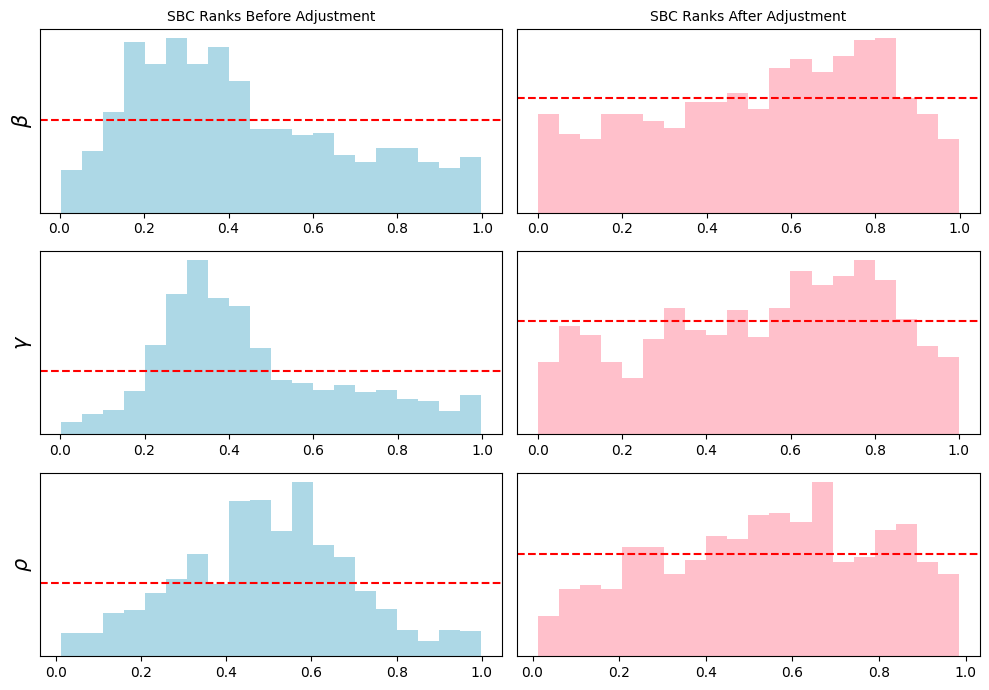

In [229]:
fig, axs = plt.subplots(3, 2, figsize=(10, 7))

ax11 = axs[0][0]
ax21 = axs[1][0]
ax31 = axs[2][0]
ax12 = axs[0][1]
ax22 = axs[1][1]
ax32 = axs[2][1]

ax11.set_title("SBC Ranks Before Adjustment", fontsize = 10)
ax12.set_title("SBC Ranks After Adjustment", fontsize = 10)

ax11.set_ylabel(r'$\beta$', fontsize = 15)
ax21.set_ylabel(r'$\gamma$', fontsize = 15)
ax31.set_ylabel(r'$\rho$', fontsize = 15)

ax11.hist(ranks_beta, bins = 20, color = "lightblue", alpha = 1, rwidth = 1, density = True)
ax21.hist(ranks_gamma, bins = 20, color = "lightblue", alpha = 1, rwidth = 1, density = True)
ax31.hist(ranks_rho, bins = 20, color = "lightblue", alpha = 1, rwidth = 1, density = True)
ax12.hist(ranks_beta_adj, bins = 20, color = "pink", alpha = 1, rwidth = 1, density = True)
ax22.hist(ranks_gamma_adj, bins = 20, color = "pink", alpha = 1, rwidth = 1, density = True)
ax32.hist(ranks_rho_adj, bins = 20, color = "pink", alpha = 1, rwidth = 1, density = True)

for p_idx in range(3):
    for idx in range(2):
        ax = axs[p_idx][idx]
        ax.axhline(1, color='red', linestyle='--', label='Uniform (ideal)')
        ax.set_yticks([])


plt.tight_layout()
plt.show()

##### Posterior Predictive Check

In [230]:
def run_ppc(predicted_params, n = 500, title = "Empty"):
    indices = rng.choice(len(predicted_params), size = n, replace = False)
    infected_pos = np.zeros((n, 201))
    rewire_pos = np.zeros((n, 201))
    degree_pos = np.zeros((n, 31))

    for i, idx in enumerate(indices):
        beta, gamma, rho = predicted_params[idx]
        infected_pos[i], rewire_pos[i], degree_pos[i] = simulate(beta, gamma, rho)

    infect_peak_sim_pos = np.max(infected_pos, axis = 1)
    infect_peak_obs     = np.max(true_infected, axis = 1)

    rewire_peak_sim_pos = np.max(rewire_pos, axis = 1)
    rewire_peak_obs = np.max(true_rewire, axis = 1)

    def three_dist(inf, rew):
        denom = np.max(inf, axis = 1)
        denom_0 = np.where(denom > 1e-10, denom, 0)
        return np.max(rew, axis = 1) / denom_0
    
    three_dist_sim_post = three_dist(infected_pos, rewire_pos)
    three_dist_obs      = three_dist(true_infected, true_rewire)
    
    idx = np.random.choice(len(param_values), size = n, replace = False)

    infected_max_all = np.max(infected_sim[idx, 0], axis = 1)
    infected_max_all_clip = infected_max_all[(infected_max_all > np.percentile(infected_max_all, 5)) & (infected_max_all < np.percentile(infected_max_all, 95))]
    rewire_peak_all  = np.max(rewire_sim[idx, 0], axis = 1)
    rewire_peak_all_clip = rewire_peak_all[(rewire_peak_all > np.percentile(rewire_peak_all, 5)) & (rewire_peak_all < np.percentile(rewire_peak_all, 95))]
    three_dist_all = three_dist(infected_sim[idx, 0], rewire_sim[idx, 0])
    three_dist_all_clip = three_dist_all[(three_dist_all > np.percentile(three_dist_all, 5)) & (three_dist_all < np.percentile(three_dist_all, 95))]


    fig, axs = plt.subplots(2, 3, figsize = (12, 7)) 

    fig.suptitle(f"Posterior Predictive Checks: {title}", fontsize = 15)

    ax11 = axs[0][0]
    ax12 = axs[0][1]
    ax13 = axs[0][2]
    ax21 = axs[1][0]
    ax22 = axs[1][1]
    ax23 = axs[1][2]
    
    ax11.hist(infect_peak_sim_pos, bins = 30, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True, label = "Simulated")
    ax11.hist(infect_peak_obs, bins = 10, color = "pink", alpha = 0.5, rwidth = 0.8, density = True, label = "Observed")
    ax11.hist(infected_max_all_clip, bins = 30, color = "orange", alpha = 0.5, rwidth = 0.8, density = True, label = "All Simulated")
    ax11.set_title("Peak Infected Fraction", fontsize = 12)
    ax12.hist(rewire_peak_sim_pos, bins = 30, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True)
    ax12.hist(rewire_peak_obs, bins = 10, color = "pink", alpha = 0.5, rwidth = 0.8, density = True)
    ax12.hist(rewire_peak_all_clip, bins = 30, color = "orange", alpha = 0.5, rwidth = 0.8, density = True)
    ax12.set_title("Peak Rewire Count", fontsize = 12)
    ax13.hist(three_dist_sim_post, bins = 30, color = "lightblue", alpha = 0.8, rwidth = 0.8, density = True)
    ax13.hist(three_dist_obs, bins = 10, color = "pink", alpha = 0.5, rwidth = 0.8, density = True)
    ax13.hist(three_dist_all_clip, bins = 30, color = "orange", alpha = 0.5, rwidth = 0.8, density = True)
    ax13.set_title("Peak Infected / Peak Rewire", fontsize = 12)

    for i in range(n):
        ax21.plot(infected_pos[i], color = "blue", alpha = 0.1, linewidth = 0.1)
        ax22.plot(rewire_pos[i], color = "blue", alpha = 0.1, linewidth = 0.1)
        ax23.scatter(np.arange(31), degree_pos[i], color = "blue", alpha = 0.1, s = 0.1)
    
    ax21.set_title("Infection Fraction Time Series", fontsize = 12)
    ax22.set_title("Rewire Count Time Series", fontsize = 12)
    ax23.set_title("Degree Distribution", fontsize = 12)

    ax21.set_xlim(0, 100)
    ax22.set_xlim(0, 25)

    for p_idx in range(2):
        for idx in range(3):
            ax = axs[p_idx][idx]
            ax.set_yticks([])

    ax21.plot(true_infected_avg, color = 'red', alpha = 0.7, linewidth = 0.9)
    ax21.fill_between(t, true_infected_avg - 2 * true_infected_std, true_infected_avg + 2 * true_infected_std, alpha = 0.1, color = 'red')

    ax22.plot(true_rewiring_avg, color = 'red', linewidth = 0.9)
    ax22.fill_between(t, np.maximum(0, true_rewiring_avg - 2 * true_rewiring_std), true_rewiring_avg + 2 * true_rewiring_std, alpha = 0.1, color = 'red')

    ax23.scatter(x_deg, true_final_avg, s = 4, color = 'red', alpha = 0.7)
    ax23.fill_between(x_deg, true_final_avg - 2 * true_final_std, true_final_avg + 2 * true_final_std, alpha = 0.1, color = 'red')
    
    handles, labels = axs[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    plt.show()

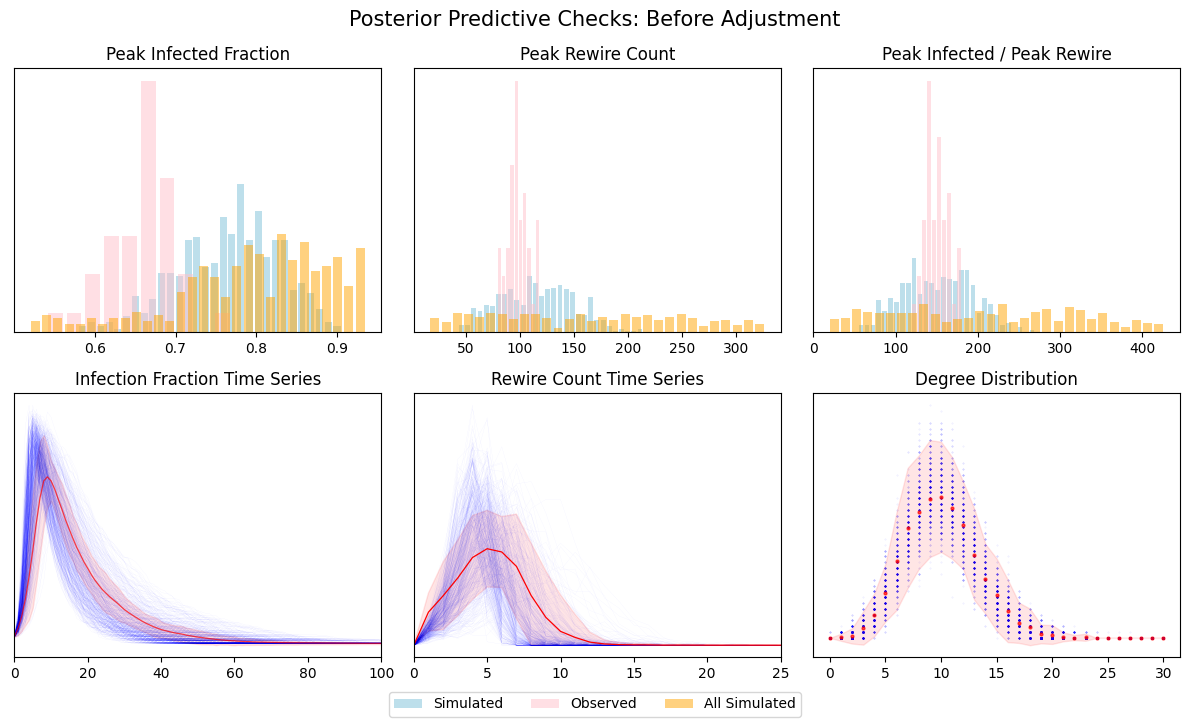

In [231]:
run_ppc(param_values[distance_sum3_3 < epsilon_sum3_3], title = "Before Adjustment")

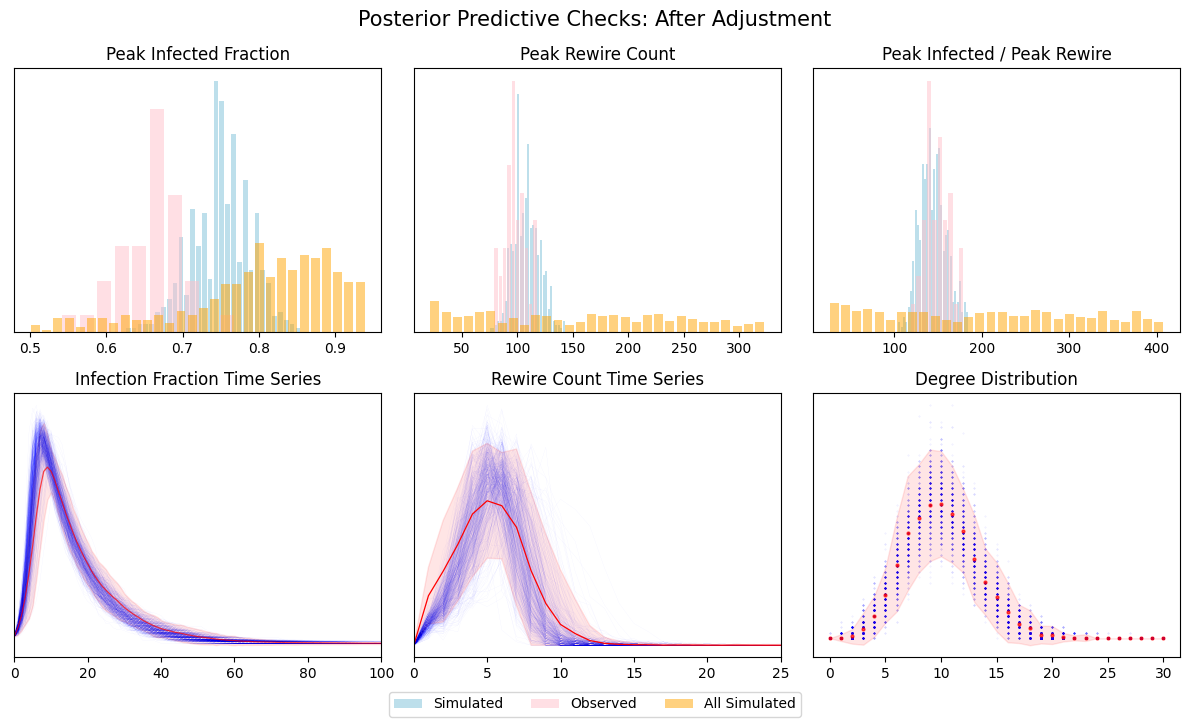

In [232]:
run_ppc(adjusted_params_both, title = "After Adjustment")